In [1]:
MLFLOW_URI = "192.168.1.254:5000"
N_TRIALS = 30
N_EPOCHS_PER_TRIAL = 20
N_SAMPLES = 4_000
DATA_DIR = "./data/datasets"

In [2]:
import optuna
from rustic_ml.training.setup import setup_device
from rustic_ml.the_decider.hpo import HpoConfig, create_study, make_objective

device = setup_device()
print(f"device: {device}")

hpo_cfg = HpoConfig(
    mlflow_uri = MLFLOW_URI,
    n_samples = N_SAMPLES,
    n_epochs = N_EPOCHS_PER_TRIAL,
    data_dir = DATA_DIR
)

CUDA detected — using AMD Radeon Graphics
device: cuda


/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory


In [3]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = create_study(mlflow_uri=MLFLOW_URI)
study.optimize(
    make_objective(device, hpo_cfg),
    n_trials = N_TRIALS,
    show_progress_bar=True
)

print(f"Completed trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])}")
print(f"Pruned trials    : {len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])}")
print(f"Best top1        : {study.best_value:.4f}")
print(f"Best params      : {study.best_params}")

  0%|          | 0/30 [00:00<?, ?it/s]

MLflow connected: 192.168.1.254:5000  (experiment: TheDecider-HPO)


/home/minigrim0/Documents/code/rust/rustic/dev/.venv/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


MLflow connected: 192.168.1.254:5000  (experiment: TheDecider-HPO)
MLflow connected: 192.168.1.254:5000  (experiment: TheDecider-HPO)
MLflow connected: 192.168.1.254:5000  (experiment: TheDecider-HPO)
MLflow connected: 192.168.1.254:5000  (experiment: TheDecider-HPO)
MLflow connected: 192.168.1.254:5000  (experiment: TheDecider-HPO)
MLflow connected: 192.168.1.254:5000  (experiment: TheDecider-HPO)
MLflow connected: 192.168.1.254:5000  (experiment: TheDecider-HPO)
MLflow connected: 192.168.1.254:5000  (experiment: TheDecider-HPO)
MLflow connected: 192.168.1.254:5000  (experiment: TheDecider-HPO)
MLflow connected: 192.168.1.254:5000  (experiment: TheDecider-HPO)
MLflow connected: 192.168.1.254:5000  (experiment: TheDecider-HPO)
MLflow connected: 192.168.1.254:5000  (experiment: TheDecider-HPO)
MLflow connected: 192.168.1.254:5000  (experiment: TheDecider-HPO)
MLflow connected: 192.168.1.254:5000  (experiment: TheDecider-HPO)
MLflow connected: 192.168.1.254:5000  (experiment: TheDecider-

/tmp/ipykernel_109378/4187338042.py:4: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)


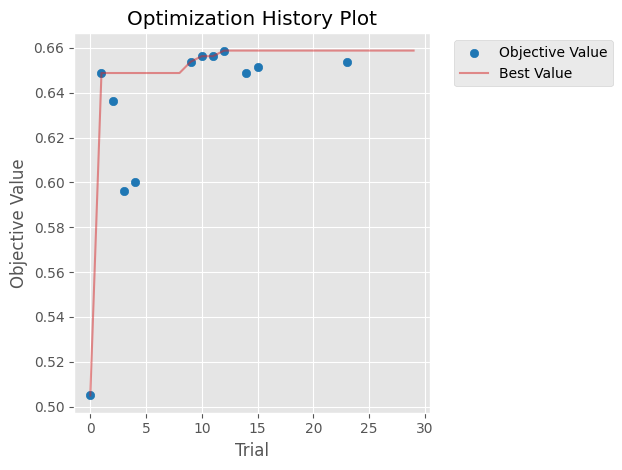

In [14]:
# Optimization history
import matplotlib.pyplot as plt                                                                                                                                                              
from optuna.visualization.matplotlib import plot_optimization_history
plot_optimization_history(study)
plt.tight_layout()
plt.show()

/tmp/ipykernel_109378/3137170746.py:4: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


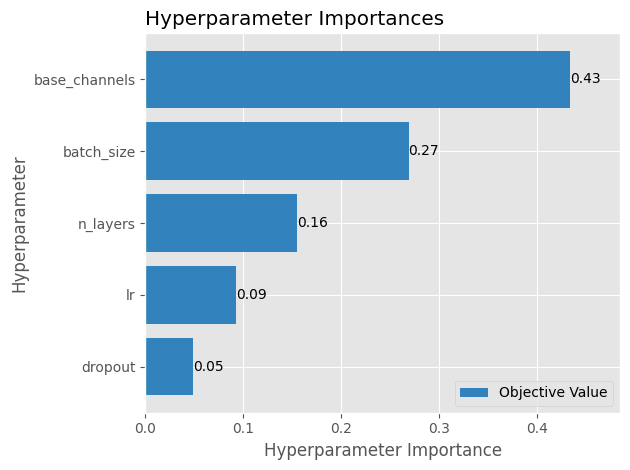

In [15]:
# Parameter importance
from optuna.visualization.matplotlib import plot_param_importances

plot_param_importances(study)
plt.tight_layout()
plt.show()

/tmp/ipykernel_109378/3156400473.py:4: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  plot_parallel_coordinate(study)


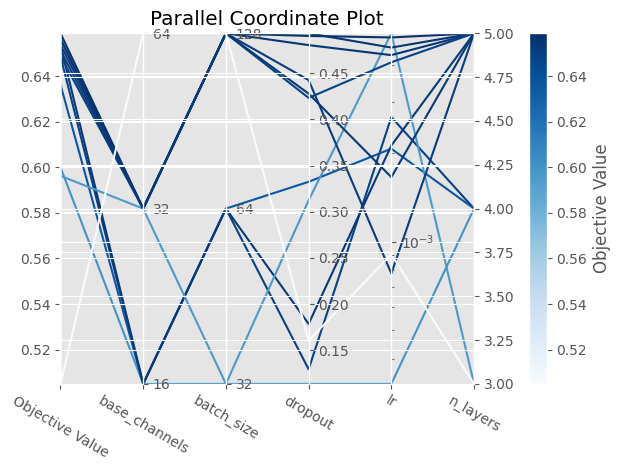

In [16]:
# Parallel coordinates
from optuna.visualization.matplotlib import plot_parallel_coordinate

plot_parallel_coordinate(study)
plt.tight_layout()
plt.show()

In [10]:
# Best trial summary
import pandas as pd

best = study.best_trial
rows = [{"param": k, "value": v} for k, v in best.params.items()]
display(pd.DataFrame(rows).set_index("param"))
print(f"Best top1 accuracy: {best.value:.4f}")

,value
param,
n_layers,5.000000
base_channels,32.000000
dropout,0.490224
lr,0.004960
batch_size,128.000000


Best top1 accuracy: 0.6587
